## Nearest Neighbor Class Fidelity (cf) Metric Implementation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.decomposition import PCA, KernelPCA
from sklearn.feature_selection import RFE
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import MDS, TSNE
from umap import UMAP

%matplotlib inline

## Nearest Neighbor Class Fidelity (cf) Metric
$\text{fidelity}_k$ - wiernosć klasowa dla $k$ sąsiadów

$k$ - aktualna liczba rozważanych sąsiadów

$K_{\text{max}}$ - maksymalna liczba sąsiadów (=100)

$\text{hits}_k (i)$ - liczba sąsiadów punktu $i$ z właściwej klasy

$N$ - całkowita liczba punktów danych

$$
$$

$$
\text{NNCF} = \frac{1}{K_{\text{max}}} \sum_{k=1}^{K_{\text{max}}} \text{fidelity}_k
$$

$$
\text{fidelity}_k = \frac{1}{k \cdot N} \sum_{i = 1}^{N} \text{hits}_k (i)
$$
gdzie $\text{hits}_k$ to liczba spośród $k$ najbliższych sąsiadów punktu $y_i$ (przestrzeń niskowymiarowa), które należą do tej samej klasy co $x_i$ (przestrzeń oryginalna).

In [37]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

class NearestNeighborClassFidelity:
    def __init__(self, X_low: np.ndarray, y: np.array, k_max: int = 100):
        self.X_low = X_low
        self.y = y
        self.k_max = k_max

        # +1 because kneighbors includes the point itself when querying training data
        self.knn_low = NearestNeighbors().fit(X_low)
    #

    def fidelity_k(self, k: int) -> float:
        n = len(self.y)

        # Find k+1 neighbors (index 0 is the point itself - will be excluded)
        _, neighbor_indices = self.knn_low.kneighbors(self.X_low, n_neighbors=k + 1)
        neighbor_indices = neighbor_indices[:, 1:]  # shape: (n, k) - drop self

        # For each point i, get classes of its k neighbors
        neighbor_classes = self.y[neighbor_indices]       # shape: (n, k)
        own_classes = self.y.reshape(-1, 1)               # shape: (n, 1)

        # hits_k(i) = number of neighbors with the same class
        hits = np.sum(neighbor_classes == own_classes, axis=1)  # shape: (n,)

        return hits.sum() / (k * n)

    def compute(self) -> float:
        fidelity_scores = [self.fidelity_k(k) for k in range(1, self.k_max + 1)]
        return float(np.mean(fidelity_scores))
#

## MNIST with NNCF

### PCA

In [38]:
import mnists
mnist = mnists.MNIST()

NUM_OF_SAMPLES=10000

digits = mnist.train_images()[:NUM_OF_SAMPLES]
digits = digits.reshape(digits.shape[0], -1)

X = digits / 255
y = mnist.train_labels()[:NUM_OF_SAMPLES]

In [39]:
def scatter_2d(X, y):
    X = np.asarray(X)
    y = np.asarray(y)

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap='tab10',
        s=10,
        alpha=0.7
    )

    plt.colorbar(scatter)
    plt.show()
#

In [40]:
def plot_2d(x, y, xlabel="x", ylabel="y", title="") -> None:
    plt.figure(figsize=(8, 6))
    plt.plot(x, y)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()
#

0.3837853652587836


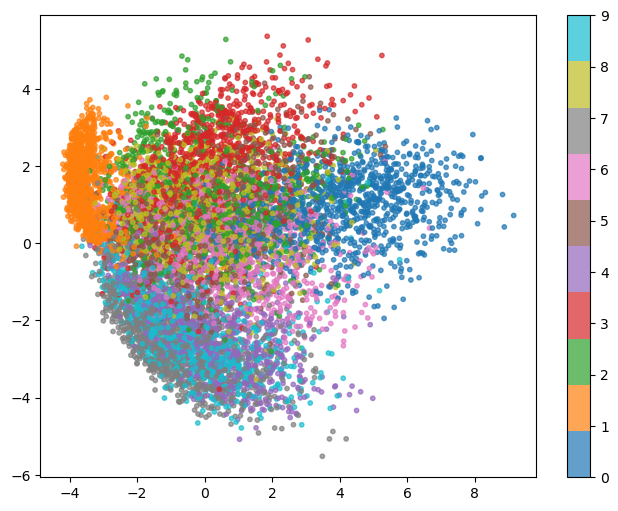

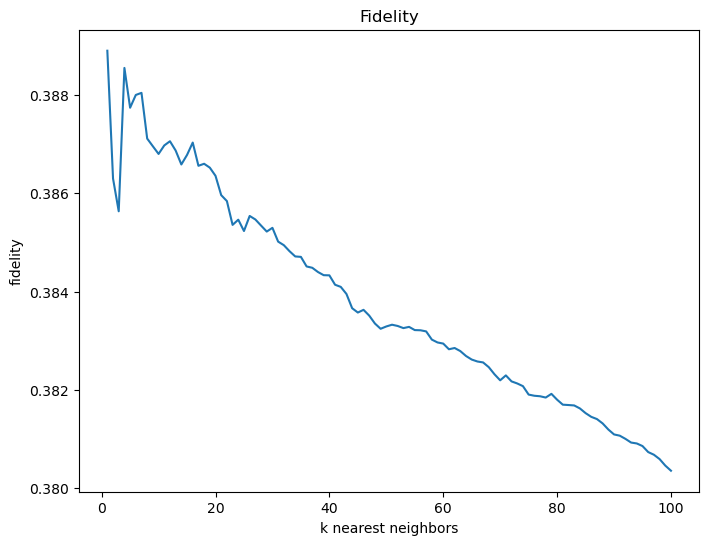

In [41]:
pca = PCA(n_components=2)
mnist_reduced_pca_two_dim = pca.fit_transform(X)

K_MAX=100
nncf = NearestNeighborClassFidelity(mnist_reduced_pca_two_dim, y, k_max=K_MAX)
print(nncf.compute())

scatter_2d(
    mnist_reduced_pca_two_dim,
    y
)

plot_2d(
    [k for k in range(1, K_MAX+1)],
    [nncf.fidelity_k(k) for k in range(1, K_MAX+1)],
    xlabel='k nearest neighbors',
    ylabel='fidelity',
    title='Fidelity'
)

0.38164096191363944


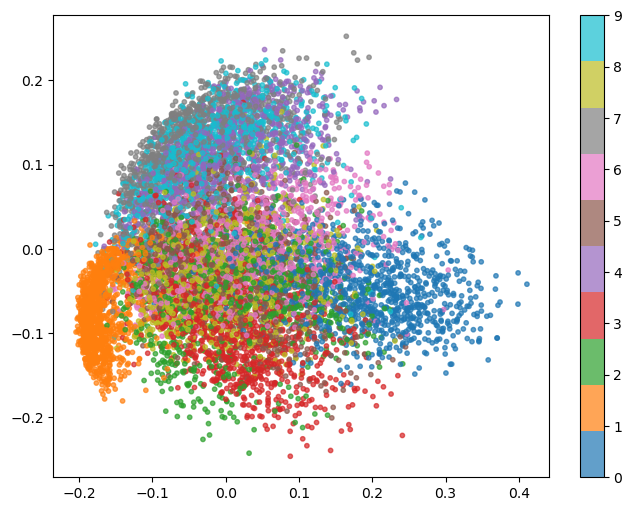

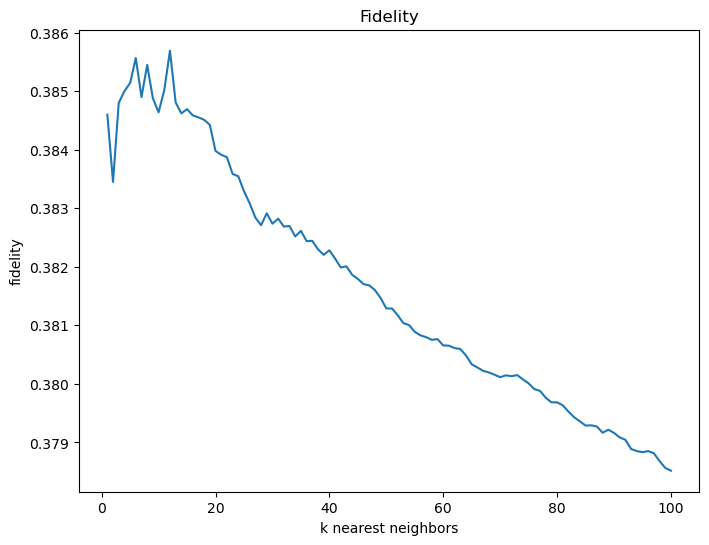

In [42]:
kernel_pca = KernelPCA(
    kernel='rbf',
    n_components=2
)
mnist_reduced_kernel_pca_two_dim = kernel_pca.fit_transform(X)

K_MAX=100
nncf = NearestNeighborClassFidelity(mnist_reduced_kernel_pca_two_dim, y, k_max=K_MAX)
print(nncf.compute())

scatter_2d(
    mnist_reduced_kernel_pca_two_dim,
    y
)

plot_2d(
    [k for k in range(1, K_MAX+1)],
    [nncf.fidelity_k(k) for k in range(1, K_MAX+1)],
    xlabel='k nearest neighbors',
    ylabel='fidelity',
    title='Fidelity'
)

## t-SNE

0.8960536200522496


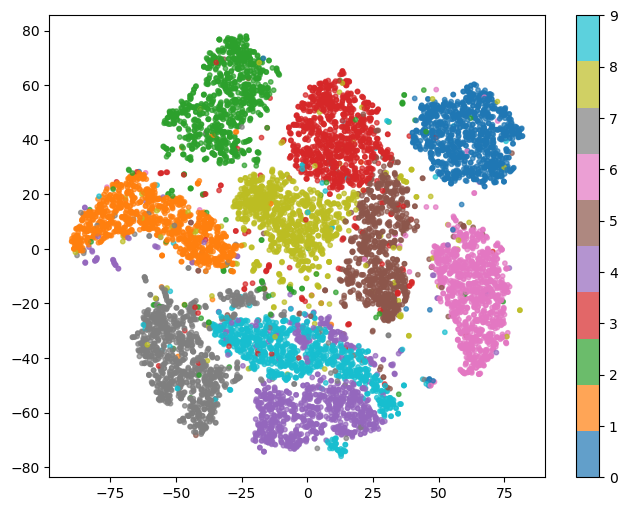

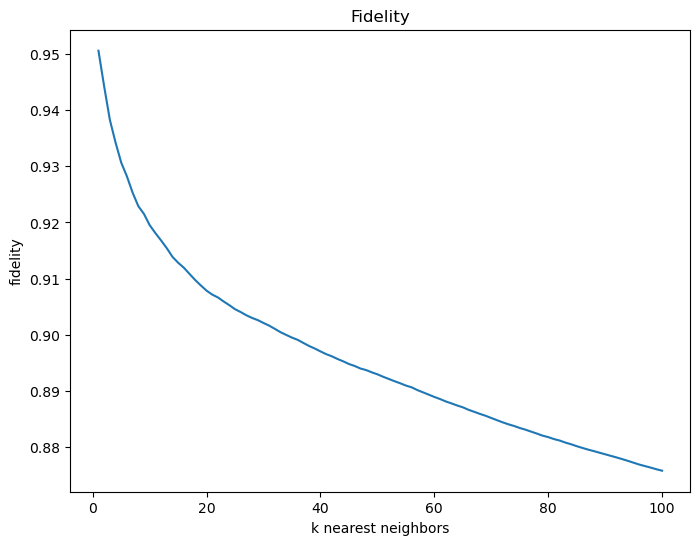

In [43]:
tsne = TSNE(n_components=2, perplexity=30)
mnist_reduced_tsne_two_dim = tsne.fit_transform(X)

K_MAX=100
nncf = NearestNeighborClassFidelity(mnist_reduced_tsne_two_dim, y, k_max=K_MAX)
print(nncf.compute())

scatter_2d(
    mnist_reduced_tsne_two_dim,
    y
)

plot_2d(
    [k for k in range(1, K_MAX+1)],
    [nncf.fidelity_k(k) for k in range(1, K_MAX+1)],
    xlabel='k nearest neighbors',
    ylabel='fidelity',
    title='Fidelity'
)

0.8860023399042073


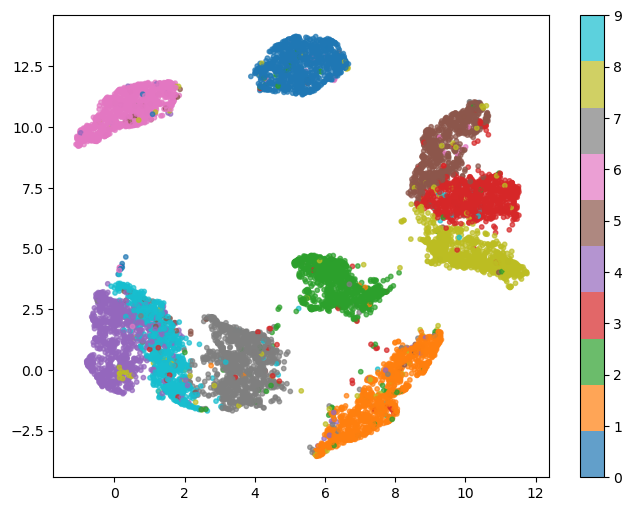

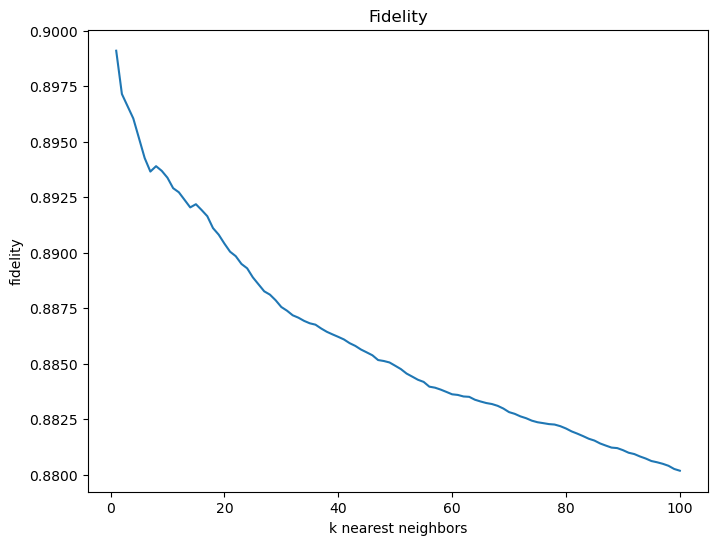

In [44]:
umap_reducer = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean'
)
mnist_reduced_umap_two_dim = umap_reducer.fit_transform(X)

K_MAX=100
nncf = NearestNeighborClassFidelity(mnist_reduced_umap_two_dim, y, k_max=K_MAX)
print(nncf.compute())

scatter_2d(
    mnist_reduced_umap_two_dim,
    y
)

plot_2d(
    [k for k in range(1, K_MAX+1)],
    [nncf.fidelity_k(k) for k in range(1, K_MAX+1)],
    xlabel='k nearest neighbors',
    ylabel='fidelity',
    title='Fidelity'
)

Metryka Nearest Neighbor Class Fidelity (NNCF) pozwala ocenić, jak dobrze metody redukcji wymiarowości zachowują strukturę klas poprzez analizę najbliższych sąsiadów w przestrzeni zredukowanej. Wyższe wartości NNCF oznaczają, że punkty należące do tej samej klasy pozostają blisko siebie po redukcji wymiarowości, co wskazuje na lepsze zachowanie relacji klasowych.

Przeprowadziłem analizy dla trzech metod: PCA (z kernelem oraz bez), t-SNE oraz UMAP. Warto zauważyć, że wartość referencyjna dla losowego rozmieszczenia punktów wynosi około $1/k$, gdzie $k$ to liczba klas. W analizowanym przypadku $1/k=0.1$, co oznacza, że PCA mimo stosunkowo niskiego wyniku (około 0.38) nadal zachowuje pewną strukturę klasową, jednak jest ona znacznie słabsza niż w metodach nieliniowych. Wyniki kernel PCA są zbliżone do klasycznego PCA, co sugeruje, że zastosowany kernel nie pozwolił na istotne uchwycenie nieliniowej struktury danych.

Kolejną metodą redukcji jest t-SNE. Wartość metryki wynosi w przybliżeniu 0.9, co oznacza już wysoką separację klas w niższej wymiarowości. Czas obliczeń wzrósł już nieco bardziej. Metoda UMAP także dobrze sobie radzi. Tutaj wartość wynosi około 0.89.

Jeśli chodzi o wykresy wartości `fidelity` dla liczby sąsiadów to należy zauwazyć, że wraz ze wzrostem liczby sąsiadów wartości NNCF dla t-SNE i UMAP zwykle spadają szybciej (niż w PCA), ponieważ metody te skupiają się głównie na strukturze lokalnej i gorzej zachowują relacje globalne między klastrami.

PCA (bez kernela) osiąga zazwyczaj niższe wartości NNCF, ponieważ jest metodą liniową i nie potrafi dobrze uchwycić złożonych, nieliniowych zależności między klasami.